<a href="https://colab.research.google.com/github/Ishan-debugg/Fine-Tuning-LoRA/blob/main/notebooks/phase2sft.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

"/kaggle/input/datasets/ishantarkas/phase1-curated-data/curated_data"

In [4]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
import subprocess
result = subprocess.run(["nvidia-smi"], capture_output=True, text=True)
print(result.stdout[:600])
import torch
print(f"GPUs: {torch.cuda.device_count()}x {torch.cuda.get_device_name(0)}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB per GPU")

Wed Aug 19 04:48:29 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|===============
GPUs: 2x Tesla T4
VRAM: 15.6 GB per GPU


In [5]:
import torch
print(torch.cuda.get_device_name(0))
# Should print: Tesla T4

Tesla T4


In [6]:
!pip install --upgrade unsloth-zoo -q
!pip install "unsloth[kaggle-new]" -q
!pip install "trl>=0.18.2,!=0.19.0" wandb -q

import unsloth, transformers, trl
print(f"Unsloth:      {unsloth.__version__}")
print(f"Transformers: {transformers.__version__}")
print(f"TRL:          {trl.__version__}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 24.3 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 30.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 72.5 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 82.6 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 53.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.0/225.0 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 215.0/215.0 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.7/119.7 kB 8.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.7/75.7 kB 1.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 MB 45.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 kB 4.5 MB/s eta 0:00

In [7]:
import unsloth
from unsloth import FastLanguageModel
import os, json, random, gc, torch, numpy as np
from pathlib import Path
from datetime import datetime
from datasets import load_from_disk
from trl import SFTTrainer, SFTConfig
import wandb

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

MODEL_CONFIG = {
    "base_model": "Qwen/Qwen2.5-1.5B-Instruct",
    "load_in_4bit": True,
    "max_seq_length": 1024,
    "dtype": None,
}
LORA_CONFIG = {
    "r": 16,
    "lora_alpha": 32,
    "lora_dropout": 0.05,
    "bias": "none",
    "target_modules": ["q_proj","k_proj","v_proj","o_proj",
                       "gate_proj","up_proj","down_proj"],
    "use_gradient_checkpointing": "unsloth",
    "random_state": SEED,
    "use_rslora": False,
}
TRAIN_CONFIG = {
    "num_train_epochs": 3,
    "per_device_train_batch_size": 4,
    "gradient_accumulation_steps": 4,
    "learning_rate": 2e-4,
    "warmup_ratio": 0.03,
    "lr_scheduler_type": "cosine",
    "fp16": not torch.cuda.is_bf16_supported(),
    "bf16": torch.cuda.is_bf16_supported(),
    "logging_steps": 5,
    "save_steps": 20,
    "save_total_limit": 3,
    "optim": "adamw_8bit",
    "weight_decay": 0.01,
    "max_grad_norm": 1.0,
    "output_dir": "/kaggle/working/checkpoints",
}
Path(TRAIN_CONFIG["output_dir"]).mkdir(exist_ok=True)
print("Config loaded")
print(f"  GPUs: {torch.cuda.device_count()}x {torch.cuda.get_device_name(0)}")

Config loaded
  GPUs: 2x Tesla T4


In [8]:
DATASET_PATH = "/kaggle/input/datasets/ishantarkas/phase1-curated-data/curated_data"

if not os.path.exists(DATASET_PATH):
    print("NOT FOUND. Checking /kaggle/input:")
    for item in os.listdir("/kaggle/input"):
        print(f"  {item}")
        for sub in os.listdir(f"/kaggle/input/{item}"):
            print(f"    {sub}")
else:
    dataset = load_from_disk(DATASET_PATH)
    print(f"Train:      {len(dataset['train']):,}")
    print(f"Validation: {len(dataset['validation']):,}")
    print(f"Test:       {len(dataset['test']):,}")

Train:      2,500
Validation: 2,732
Test:       2,732


In [9]:
print(f"Loading {MODEL_CONFIG['base_model']}...")
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=MODEL_CONFIG["base_model"],
    max_seq_length=MODEL_CONFIG["max_seq_length"],
    load_in_4bit=MODEL_CONFIG["load_in_4bit"],
    dtype=MODEL_CONFIG["dtype"],
)
print(f"Model loaded")
print(f"  VRAM used: {torch.cuda.memory_allocated()/1e9:.2f} GB")

Loading Qwen/Qwen2.5-1.5B-Instruct...
==((====))==  Unsloth 2026.8.18: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Model loaded
  VRAM used: 1.58 GB


In [10]:
model = FastLanguageModel.get_peft_model(
    model,
    r=LORA_CONFIG["r"],
    target_modules=LORA_CONFIG["target_modules"],
    lora_alpha=LORA_CONFIG["lora_alpha"],
    lora_dropout=LORA_CONFIG["lora_dropout"],
    bias=LORA_CONFIG["bias"],
    use_gradient_checkpointing=LORA_CONFIG["use_gradient_checkpointing"],
    random_state=LORA_CONFIG["random_state"],
    use_rslora=LORA_CONFIG["use_rslora"],
)
total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable: {trainable:,} ({trainable/total*100:.2f}%)")
print(f"Frozen:    {total-trainable:,} ({(total-trainable)/total*100:.2f}%)")

Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.05.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.
Unsloth 2026.8.18 patched 28 layers with 0 QKV layers, 0 O layers and 0 MLP layers.


Trainable: 18,464,768 (1.78%)
Frozen:    1,017,984,512 (98.22%)


In [11]:
# Cell 7 — Copy dataset to working dir first, then format
import shutil

# Copy from read-only input to writable working directory
SRC = "/kaggle/input/datasets/ishantarkas/phase1-curated-data/curated_data"
DST = "/kaggle/working/curated_data"

if not os.path.exists(DST):
    print("Copying dataset to working directory...")
    shutil.copytree(SRC, DST)
    print(f"✓ Copied to {DST}")
else:
    print(f"✓ Already exists at {DST}")

# Reload from writable location
dataset = load_from_disk(DST)
print(f"  Train:      {len(dataset['train']):,}")
print(f"  Validation: {len(dataset['validation']):,}")

# Now format — cache writes to working dir, no read-only error
def format_to_text(example):
    messages = example["messages"]
    if isinstance(messages, str):
        messages = json.loads(messages)
    return {"text": tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=False
    )}

train_dataset = dataset["train"].map(format_to_text, desc="Train")
val_dataset   = dataset["validation"].map(format_to_text, desc="Val")

print(f"\n✓ Formatting done")
print(f"  Columns: {train_dataset.column_names}")
print(f"  Sample:\n{train_dataset[0]['text'][:300]}")

Copying dataset to working directory...
✓ Copied to /kaggle/working/curated_data
  Train:      2,500
  Validation: 2,732


Train:   0%|          | 0/2500 [00:00<?, ? examples/s]

Val:   0%|          | 0/2732 [00:00<?, ? examples/s]


✓ Formatting done
  Columns: ['messages', 'function_name', 'num_calls', 'text']
  Sample:
<|im_start|>system
You are a precise function-calling assistant. Given a natural language request, extract the appropriate function call and return ONLY a valid JSON array containing the function call(s). Return no explanation, no markdown, no preamble — only the JSON array.<|im_end|>
<|im_start|>us


In [12]:
SYSTEM_PROMPT = (
    "You are a precise function-calling assistant. "
    "Given a natural language request, extract the appropriate function call "
    "and return ONLY a valid JSON array. No explanation, no markdown."
)
TEST_PROMPTS = [
    "Book a flight from Mumbai to Bangalore on August 20th for 1 passenger.",
    "Search for Italian restaurants near Connaught Place open now.",
    "Set a reminder for tomorrow 9am to call Dr. Mehta.",
    "Transfer 5000 rupees to account 9876543210 IFSC HDFC0001234.",
    "Find emails from Priya Sharma in the last 7 days.",
]

def run_inference(prompt, system=SYSTEM_PROMPT):
    messages = [{"role":"system","content":system},{"role":"user","content":prompt}]
    inputs = tokenizer.apply_chat_template(
        messages, tokenize=True, add_generation_prompt=True, return_tensors="pt"
    ).to("cuda")
    with torch.no_grad():
        outputs = model.generate(
            input_ids=inputs, max_new_tokens=256, temperature=0.1,
            do_sample=True, pad_token_id=tokenizer.eos_token_id,
        )
    return tokenizer.decode(outputs[0][inputs.shape[1]:], skip_special_tokens=True).strip()

FastLanguageModel.for_inference(model)
print("PRE-TRAINING BASELINE\n")
pre_results = []
pre_valid = 0
for i, prompt in enumerate(TEST_PROMPTS):
    resp = run_inference(prompt)
    valid = True
    try: json.loads(resp)
    except: valid = False
    if valid: pre_valid += 1
    pre_results.append({"prompt":prompt,"response":resp,"valid_json":valid})
    print(f"[{i+1}] {'OK' if valid else 'FAIL'}: {resp[:100]}")

print(f"\nBase model JSON valid: {pre_valid}/{len(TEST_PROMPTS)}")
with open("/kaggle/working/pre_training_results.json","w") as f:
    json.dump(pre_results, f, indent=2)
FastLanguageModel.for_training(model)

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


PRE-TRAINING BASELINE



Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[1] OK: ["book_flight({origin: 'Mumbai', destination: 'Bangalore', date: 'August 20th', passengers: 1})"]


Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[3] OK: ["setReminder", {"time": "tomorrow:09:00", "description": "call Dr. Mehta"}]


Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[4] OK: ["transfer", {"amount": "5000", "account_number": "9876543210", "ifsc_code": "HDFC0001234"}]
[5] OK: ["find_emails", "Priya Sharma", "last_7_days"]

Base model JSON valid: 4/5


PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): Qwen2ForCausalLM(
      (model): Qwen2Model(
        (embed_tokens): Embedding(151936, 1536, padding_idx=151654)
        (layers): ModuleList(
          (0): Qwen2DecoderLayer(
            (self_attn): Qwen2Attention(
              (q_proj): lora.Linear(
                (base_layer): Linear(in_features=1536, out_features=1536, bias=True)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=1536, out_features=16, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=16, out_features=1536, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj): 

In [13]:
if wandb.run is not None:
    wandb.finish()
from kaggle_secrets import UserSecretsClient

secrets = UserSecretsClient()
wandb_key = secrets.get_secret("WANDB_KEY")
wandb.login(key=wandb_key)

run_name = f"qwen2.5-1.5b-json-r{LORA_CONFIG['r']}"
wandb.init(project="fine-tuning-lora-dpo", name=run_name,
           tags=["sft","qlora","kaggle"])

steps_per_epoch = len(train_dataset) // (
    TRAIN_CONFIG["per_device_train_batch_size"] *
    TRAIN_CONFIG["gradient_accumulation_steps"]
)
total_steps = steps_per_epoch * TRAIN_CONFIG["num_train_epochs"]
warmup_steps = max(1, int(total_steps * TRAIN_CONFIG["warmup_ratio"]))

sft_config = SFTConfig(
    dataset_text_field="text",
    max_seq_length=MODEL_CONFIG["max_seq_length"],
    packing=True,
    dataset_kwargs={"add_special_tokens":False,"append_concat_token":False},
    output_dir=TRAIN_CONFIG["output_dir"],
    num_train_epochs=TRAIN_CONFIG["num_train_epochs"],
    per_device_train_batch_size=TRAIN_CONFIG["per_device_train_batch_size"],
    gradient_accumulation_steps=TRAIN_CONFIG["gradient_accumulation_steps"],
    learning_rate=TRAIN_CONFIG["learning_rate"],
    warmup_steps=warmup_steps,
    lr_scheduler_type=TRAIN_CONFIG["lr_scheduler_type"],
    fp16=TRAIN_CONFIG["fp16"],
    bf16=TRAIN_CONFIG["bf16"],
    logging_steps=TRAIN_CONFIG["logging_steps"],
    eval_strategy="no",
    save_steps=TRAIN_CONFIG["save_steps"],
    save_strategy="steps",
    save_total_limit=TRAIN_CONFIG["save_total_limit"],
    load_best_model_at_end=False,
    optim=TRAIN_CONFIG["optim"],
    weight_decay=TRAIN_CONFIG["weight_decay"],
    max_grad_norm=TRAIN_CONFIG["max_grad_norm"],
    report_to="wandb",
    run_name=run_name,
    seed=SEED,
    dataloader_num_workers=2,
    remove_unused_columns=False,
)
trainer = SFTTrainer(
    model=model,
    processing_class=tokenizer,
    train_dataset=train_dataset,
    args=sft_config,
)
print(f"SFTTrainer configured")
print(f"  Steps per epoch: {steps_per_epoch}")
print(f"  Total steps:     {total_steps}")
print(f"  Effective batch: {TRAIN_CONFIG['per_device_train_batch_size'] * TRAIN_CONFIG['gradient_accumulation_steps']}")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: tarkasishan7536 (tarkasishan7536-k-j-somaiya) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb: Detected [huggingface_hub.inference, openai] in use.
wandb: Use W&B Weave for improved LLM call tracing. Install Weave with `pip install weave` then add `import weave` to the top of your script.
wandb: For more information, check out the docs at: https://weave-docs.wandb.ai


Unsloth: Tokenizing ["text"] (num_proc=2):   0%|          | 0/2500 [00:00<?, ? examples/s]

Unsloth: Packing train dataset (num_proc=2):   0%|          | 0/2500 [00:00<?, ? examples/s]

🦥 Unsloth: Packing enabled - training is >2x faster and uses less VRAM!
SFTTrainer configured
  Steps per epoch: 156
  Total steps:     468
  Effective batch: 16


In [14]:
print(f"Training started at {datetime.now().strftime('%H:%M:%S')}")
trainer_stats = trainer.train()

print(f"\nDone at {datetime.now().strftime('%H:%M:%S')}")
print(f"  Time: {trainer_stats.metrics.get('train_runtime',0)/60:.1f} mins")
print(f"  Loss: {trainer_stats.metrics.get('train_loss',0):.4f}")

ADAPTER_PATH = "/kaggle/working/sft_lora_adapter"
os.makedirs(ADAPTER_PATH, exist_ok=True)
model.save_pretrained(ADAPTER_PATH)
tokenizer.save_pretrained(ADAPTER_PATH)
print(f"\nAdapter saved: {os.listdir(ADAPTER_PATH)}")

wandb.log({"final_train_loss": trainer_stats.metrics.get("train_loss",0)})
wandb.finish()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


Training started at 04:50:58


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 316 | Num Epochs = 3 | Total steps = 60
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 4 x 1) = 16
 "-____-"     Trainable parameters = 18,464,768 of 1,562,179,072 (1.18% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Unsloth: Will smartly offload gradients to save VRAM!
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Step,Training Loss
5,3.466714
10,2.078216
15,0.969040
20,0.578066
25,0.560547
30,0.538241
35,0.538461
40,0.529340
45,0.509701
50,0.498480


Unsloth: Restored added_tokens_decoder metadata in /kaggle/working/checkpoints/checkpoint-20/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /kaggle/working/checkpoints/checkpoint-40/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /kaggle/working/checkpoints/checkpoint-60/tokenizer_config.json.



Done at 05:02:10
  Time: 11.2 mins
  Loss: 0.9407


Unsloth: Restored added_tokens_decoder metadata in /kaggle/working/sft_lora_adapter/tokenizer_config.json.



Adapter saved: ['adapter_config.json', 'adapter_model.safetensors', 'chat_template.jinja', 'tokenizer_config.json', 'README.md', 'tokenizer.json']


final_train_loss,▁
train/epoch,▁▂▂▃▄▄▅▅▆▇▇██
train/global_step,▁▂▂▃▄▄▅▅▆▇▇███
train/grad_norm,█▅▃▁▁▁▁▁▁▁▁▁
train/learning_rate,▃▅██▇▆▅▄▃▂▁▁
train/loss,█▅▂▁▁▁▁▁▁▁▁▁
final_train_loss,0.94067
total_flos,7455586790559744.0
train/epoch,3
train/global_step,60
train/grad_norm,0.16763


In [15]:
gc.collect(); torch.cuda.empty_cache()
FastLanguageModel.for_inference(model)
print("POST-TRAINING\n")
post_valid = 0
for i, item in enumerate(pre_results):
    resp = run_inference(item["prompt"])
    valid = True
    try: json.loads(resp)
    except: valid = False
    if valid: post_valid += 1
    print(f"[{i+1}] BEFORE:{'OK' if item['valid_json'] else 'X'} AFTER:{'OK' if valid else 'X'}")
    print(f"  {resp[:120]}")
print(f"\nBEFORE: {sum(1 for r in pre_results if r['valid_json'])}/5")
print(f"AFTER:  {post_valid}/5")

Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


POST-TRAINING



Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[1] BEFORE:OK AFTER:OK
  [{"name": "book_flight", "arguments": {"origin_city": "Mumbai", "destination_city": "Bangalore", "departure_date": "2023


Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[2] BEFORE:X AFTER:OK
  [{"name": "search_restaurants", "arguments": {"location": "Connaught Place", "radius": 500, "category": "Italian"}}]


Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[3] BEFORE:OK AFTER:OK
  [{"name": "set_reminder", "arguments": {"reminder_time": "2023-10-05T09:00:00Z"}}]


Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[4] BEFORE:OK AFTER:OK
  [{"name": "transfer", "arguments": {"amount": 5000, "account_number": "9876543210", "ifsc_code": "HDFC0001234"}}]
[5] BEFORE:OK AFTER:OK
  [{"name": "search_by_email", "arguments": {"email": "priyasharma@example.com"}}]

BEFORE: 4/5
AFTER:  5/5


In [16]:
# Cell 12 — Zip + Final Summary

import shutil, os, json

# Zip the adapter
shutil.make_archive(
    "/kaggle/working/sft_lora_adapter",
    "zip",
    "/kaggle/working/sft_lora_adapter"
)
print("✓ Adapter zipped")

# Save training summary
summary = {
    "base_model": MODEL_CONFIG["base_model"],
    "lora_rank": LORA_CONFIG["r"],
    "lora_alpha": LORA_CONFIG["lora_alpha"],
    "max_seq_length": MODEL_CONFIG["max_seq_length"],
    "train_examples": len(dataset["train"]),
    "epochs": TRAIN_CONFIG["num_train_epochs"],
    "final_train_loss": round(trainer_stats.metrics.get("train_loss", 0), 4),
    "training_minutes": round(trainer_stats.metrics.get("train_runtime", 0)/60, 1),
    "pre_json_valid": f"{sum(1 for r in pre_results if r['valid_json'])}/{len(pre_results)}",
    "post_json_valid": f"{post_valid}/5",
}

with open("/kaggle/working/training_summary.json", "w") as f:
    json.dump(summary, f, indent=2)
print("✓ Summary saved")

# List all output files
print("\n── Files in /kaggle/working/ ──")
for f in sorted(os.listdir("/kaggle/working/")):
    path = f"/kaggle/working/{f}"
    try:
        size = os.path.getsize(path)
        label = f"{size/1e6:.1f} MB" if size > 1e6 else f"{size/1e3:.0f} KB"
    except:
        label = "dir"
    print(f"  {f:<45} {label}")

# Print summary
print("\n── Training Summary ──")
for k, v in summary.items():
    print(f"  {k}: {v}")

print("\n── PHASE 2 COMPLETE ──")
print("\nNext steps:")
print("  1. Output tab → download sft_lora_adapter.zip")
print("  2. Push adapter to GitHub: models/sft_lora_adapter/")
print("  3. Write learning checkpoint answers in your notebook")
print("  4. Move to Phase 3 (DPO)")

✓ Adapter zipped
✓ Summary saved

── Files in /kaggle/working/ ──
  .virtual_documents                            4 KB
  checkpoints                                   4 KB
  curated_data                                  4 KB
  huggingface_tokenizers_cache                  4 KB
  pre_training_results.json                     1 KB
  sft_lora_adapter                              4 KB
  sft_lora_adapter.zip                          70.4 MB
  training_summary.json                         0 KB
  unsloth_compiled_cache                        4 KB
  wandb                                         4 KB

── Training Summary ──
  base_model: Qwen/Qwen2.5-1.5B-Instruct
  lora_rank: 16
  lora_alpha: 32
  max_seq_length: 1024
  train_examples: 2500
  epochs: 3
  final_train_loss: 0.9407
  training_minutes: 11.2
  pre_json_valid: 4/5
  post_json_valid: 5/5

── PHASE 2 COMPLETE ──

Next steps:
  1. Output tab → download sft_lora_adapter.zip
  2. Push adapter to GitHub: models/sft_lora_adapter/
  3. Writ

In [17]:
from trl import SFTTrainer

In [18]:
trainer = SFTTrainer(
    model=model,
    train_dataset=train_dataset,
    )

Unsloth: Tokenizing ["text"] (num_proc=2):   0%|          | 0/2500 [00:00<?, ? examples/s]

In [19]:
trainer_stats = trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 2,500 | Num Epochs = 3 | Total steps = 939
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 2
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 2 x 1) = 8
 "-____-"     Trainable parameters = 18,464,768 of 1,562,179,072 (1.18% trained)


Step,Training Loss
1,0.327027
2,0.537373
3,0.432498
4,0.461939
5,0.617835
6,0.441791
7,0.517129
8,0.545600
9,0.506321
10,0.349314


Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.
Unsloth: Will smartly offload gradients to save VRAM!


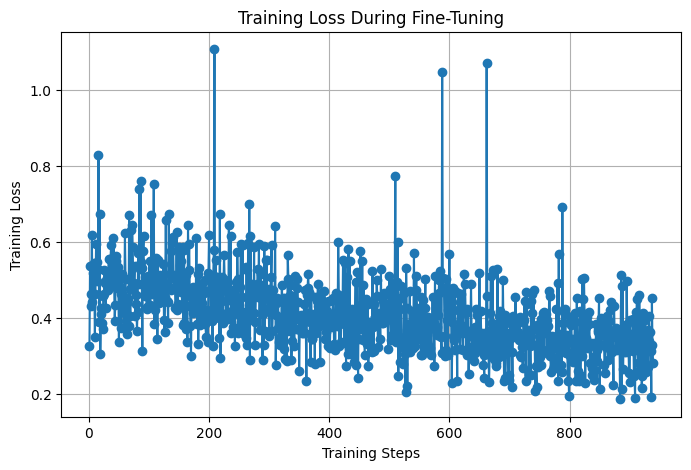

In [20]:
import matplotlib.pyplot as plt

logs = trainer.state.log_history

steps = []
losses = []

for log in logs:
    if "loss" in log:
        steps.append(log["step"])
        losses.append(log["loss"])

plt.figure(figsize=(8, 5))
plt.plot(steps, losses, marker="o")
plt.xlabel("Training Steps")
plt.ylabel("Training Loss")
plt.title("Training Loss During Fine-Tuning")
plt.grid(True)
plt.show()